# Regression results from real app data

This notebook reuses existing classes from the app codebase (Postgres repositories, data initialization, and prediction services) to train and evaluate regression models on real persisted data.

In [1]:


import matplotlib.pyplot as plt
import numpy as np
from main import museum_repository
from prediction.linear_regression_prediction_service import LinearRegressionPredictionService
from prediction.sgd_regressor_prediction_service import SgdRegressorPredictionService
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
museums = list(museum_repository.find_all())
if not museums:
    raise ValueError("No museums found in database. Populate data first and rerun.")

len(museums)

63

In [3]:
X = np.array([museum.city.population for museum in museums], dtype=int)
y_true = np.array([museum.annual_visitor for museum in museums], dtype=int)

linear_service = LinearRegressionPredictionService(museum_repository)
sgd_service = SgdRegressorPredictionService(museum_repository, batch_size=1000, epochs=20)

y_pred_linear = np.array([linear_service.predict(int(population)) for population in X], dtype=int)
y_pred_sgd = np.array([sgd_service.predict(int(population)) for population in X], dtype=int)

# Access internal sklearn model in LinearRegressionPredictionService for direct model output
y_pred_linear_model = linear_service._model.predict(X.reshape(-1, 1))

Starting training model...
Model is trained


In [4]:
def compute_metrics(y_actual: np.ndarray, y_predicted: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_actual, y_predicted)),
        "rmse": float(np.sqrt(mean_squared_error(y_actual, y_predicted))),
        "r2": float(r2_score(y_actual, y_predicted)),
    }


linear_metrics = compute_metrics(y_true, y_pred_linear)
sgd_metrics = compute_metrics(y_true, y_pred_sgd)

linear_metrics, sgd_metrics

({'mae': 1379090.6825396826,
  'rmse': 1773691.8848314933,
  'r2': 0.0453690900946665},
 {'mae': 1357304.746031746,
  'rmse': 1784402.0187319568,
  'r2': 0.033805533231729856})

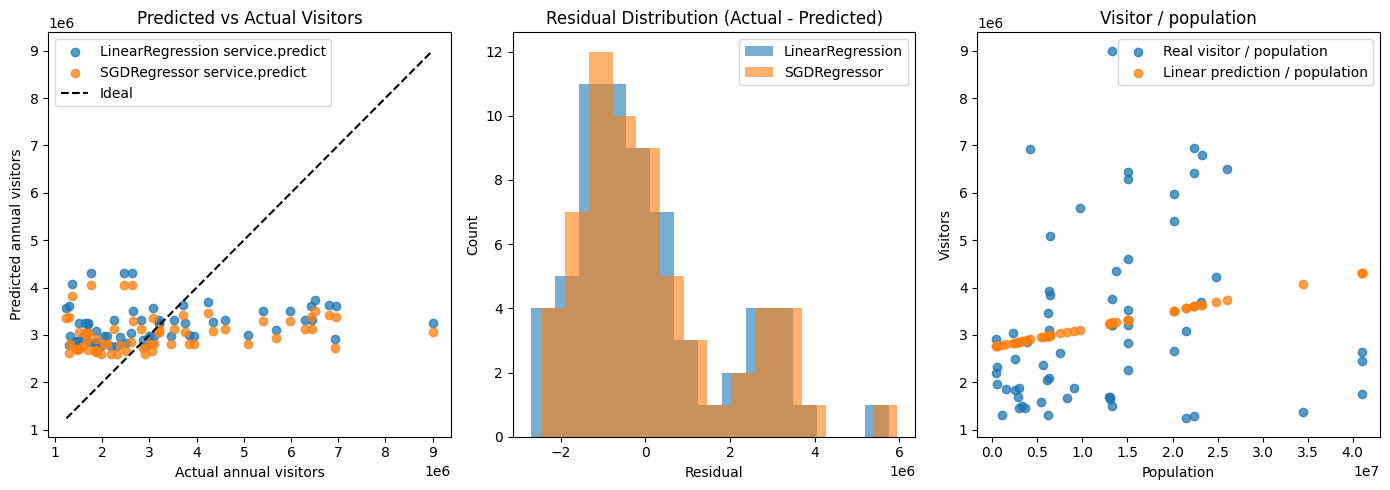

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].scatter(y_true, y_pred_linear, label="LinearRegression service.predict", alpha=0.75, color="tab:blue")
axes[0].scatter(y_true, y_pred_sgd, label="SGDRegressor service.predict", alpha=0.75, color="tab:orange")
line_min = min(y_true.min(), y_pred_linear.min(), y_pred_sgd.min())
line_max = max(y_true.max(), y_pred_linear.max(), y_pred_sgd.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "k--", label="Ideal")
axes[0].set_title("Predicted vs Actual Visitors")
axes[0].set_xlabel("Actual annual visitors")
axes[0].set_ylabel("Predicted annual visitors")
axes[0].legend()

linear_residuals = y_true - y_pred_linear
sgd_residuals = y_true - y_pred_sgd
axes[1].hist(linear_residuals, bins=15, alpha=0.6, label="LinearRegression", color="tab:blue")
axes[1].hist(sgd_residuals, bins=15, alpha=0.6, label="SGDRegressor", color="tab:orange")
axes[1].set_title("Residual Distribution (Actual - Predicted)")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].legend()

axes[2].scatter(X, y_true, label="Real visitor / population", alpha=0.75, color="tab:blue")
axes[2].scatter(X, y_pred_linear, label="Linear prediction / population", alpha=0.75, color="tab:orange")
line_min = min(X.min(), y_true.min(), y_pred_linear.min())
line_max = max(X.max(), y_true.max(), y_pred_linear.max())
#axes[2].plot([line_min, line_max], [line_min, line_max], "k--", label="Ideal")
axes[2].set_title("Visitor / population")
axes[2].set_xlabel("Population")
axes[2].set_ylabel("Visitors")
axes[2].legend()

plt.tight_layout()
plt.show()

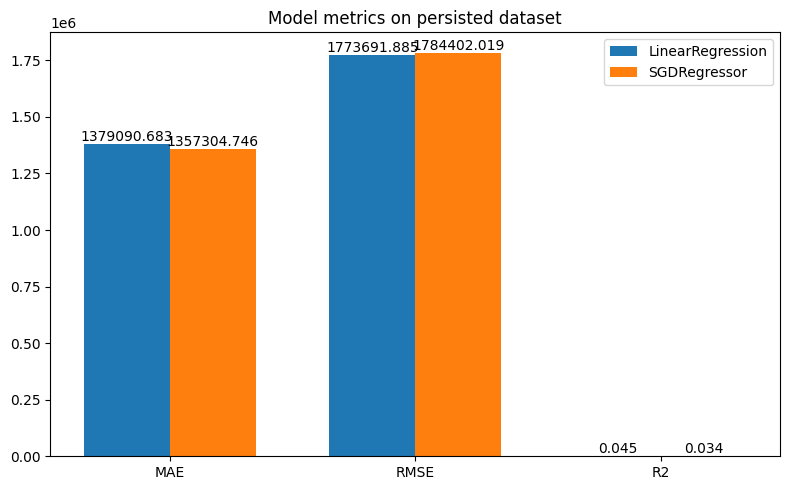

In [6]:
labels = ["MAE", "RMSE", "R2"]
linear_values = [linear_metrics["mae"], linear_metrics["rmse"], linear_metrics["r2"]]
sgd_values = [sgd_metrics["mae"], sgd_metrics["rmse"], sgd_metrics["r2"]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, linear_values, width, label="LinearRegression", color="tab:blue")
ax.bar(x + width / 2, sgd_values, width, label="SGDRegressor", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Model metrics on persisted dataset")
ax.legend()

for index, value in enumerate(linear_values):
    ax.text(index - width / 2, value, f"{value:.3f}", ha="center", va="bottom")

for index, value in enumerate(sgd_values):
    ax.text(index + width / 2, value, f"{value:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()